## XRD Analysis

##### Caleb Fink 4/24/26

In progress XRD analysis. This notebook imports the fitting class PeakFitXRD, which is saved in the corresponding python file XRD_fits.py. There are also some plotting functions that are saved in XRD_plot_utils.py

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize, approx_fprime
from scipy.special import voigt_profile
from math import lgamma
import re

from glob import glob

from matplotlib import rcParams
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from XRD_fits import PeakFitXRD, fits_to_dataframe, compute_ratio_with_error
import XRD_plot_utils as pltxrd

%load_ext autoreload
%autoreload 2

In [2]:
# helper function to get labels
def get_jt_label(f):
    match = re.search(r'JT\d+', f)
    return match.group(0) if match else None

# dumb function to sort files by pressure
def sort_by_pressure(files, pressure_dict):
    files_sorted = sorted(
        files,
        key=lambda f: -pressure_dict[get_jt_label(f)]
    )
    return files_sorted

# put datafile into pandas dataframe
def read_data(f):
    df = pd.read_table(f, sep=r'\s+', names=['x', 'y', 'z'], skiprows=[0, 1])
    return df

#### Define pressures and load files

In [3]:
# define dictionary of preasures from JT
pressures = {'JT10' : -527.4,
             'JT9'  : -598.4,
             'JT8'  : -542.3,
             'JT7'  : -400.5,
             'JT6'  : -373.2,
             'JT5'  : -371.3,
             'JT4'  : -56.3,
             'JT3'  : -737.4,
             'JT2'  : -408.2,
             'JT1'  : -981.9,}

pressures_error = {'JT10' : 33.2,
             'JT9'  : 41.4	,
             'JT8'  : 56.5	,
             'JT7'  : 21.8,
             'JT6'  : 26.4,
             'JT5'  : 47.2	,
             'JT4'  : 32.7,
             'JT3'  : 71.7	,
             'JT2'  : 60.4	,
             'JT1'  : 81.7	,}



files = glob('./data/20250611_JT_re plot/20250611_JT*')
# filter out junk files - all these files are not to be used? check with JT
bad_words = ['Si', 'rot', 'JT4', '3090']

# remove 'bad' files 
files_high = [f for f in files if not any(word in f for word in bad_words)]
files_low = glob('./data/20250611_JT_re plot/JT*')

# sort the files by pressure
files_high = sort_by_pressure(files_high, pressures)
files_low = sort_by_pressure(files_low, pressures)


# check the order
for ii, f in enumerate(files_high):
    print(pressures[get_jt_label(files_high[ii])])




-371.3
-373.2
-400.5
-408.2
-527.4
-542.3
-598.4
-737.4
-981.9


### Look at individual fits


===== JT9: one-peak model =====
  success = True
  NLL     = 528.3315799305254
  AIC     = 1066.6631598610509
  BIC     = 1085.1653777280044
  params  = [1.32683208e+02 3.81099549e+01 1.66278897e-01 6.85047277e-02
 0.00000000e+00]

===== JT9: stable two-peak model =====
  success   = True
  best init = [1.32683208e+02 3.81099549e+01 1.66278897e-01 6.85047277e-02
 2.65366417e+01 5.00000000e-02 0.00000000e+00]
  NLL       = 516.370192537478
  AIC       = 1046.740385074956
  BIC       = 1072.643490088691
  params    = [1.29335361e+02 3.81038196e+01 1.68342278e-01 5.87318004e-02
 3.06943665e+00 5.60190848e-01 0.00000000e+00]
  ΔAIC(two-one) = -19.92
  ΔBIC(two-one) = -12.52

  covariance methods: inv inv


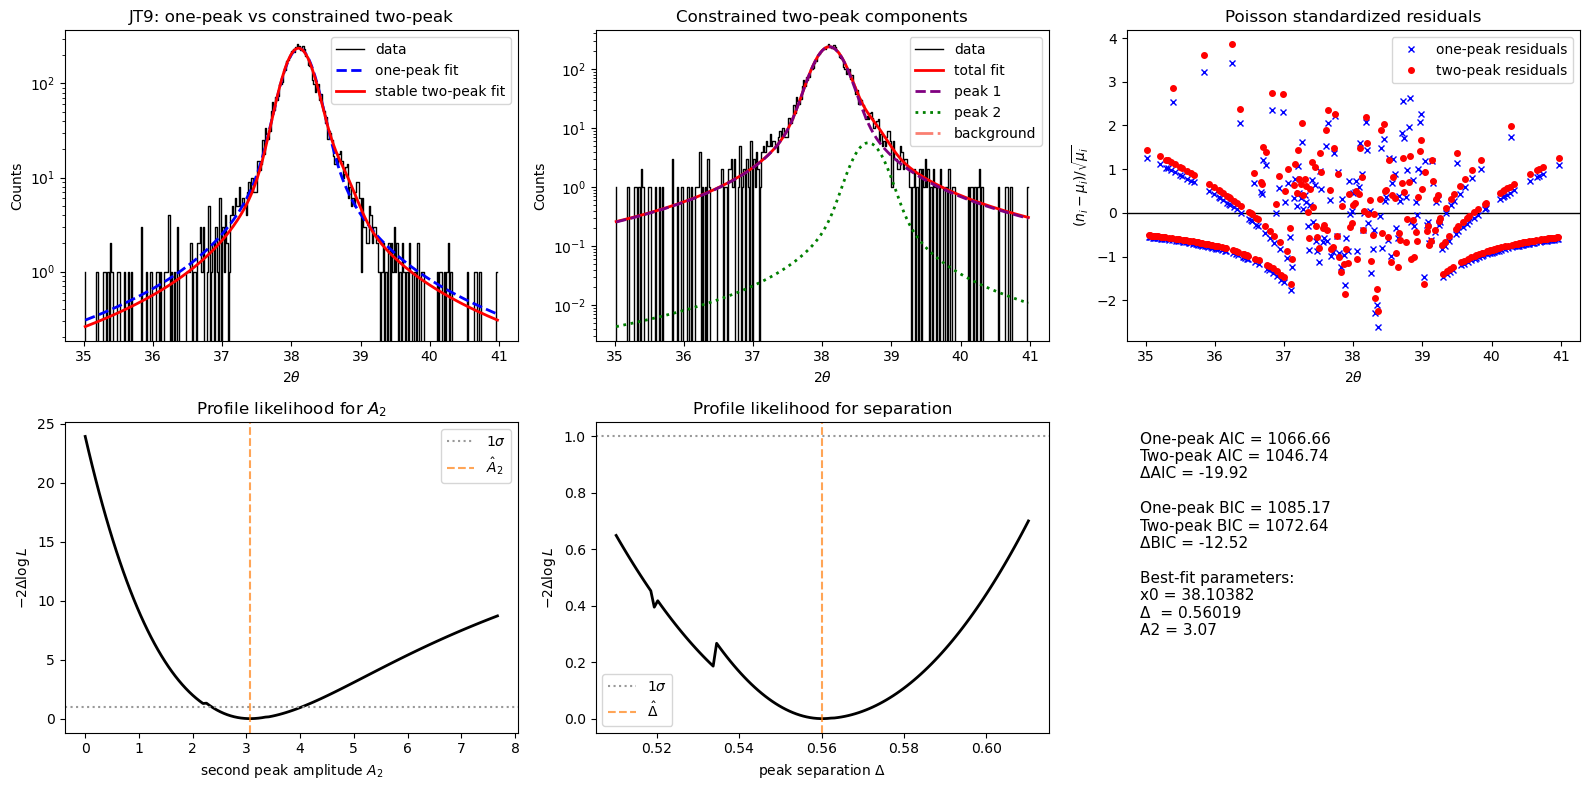


===== JT3: one-peak model =====
  success = True
  NLL     = 1444.1313202684096
  AIC     = 2898.262640536819
  BIC     = 2916.7815529101003
  params  = [2.19936451e+03 3.81757110e+01 2.21380947e-01 8.73553450e-02
 0.00000000e+00]

===== JT3: stable two-peak model =====
  success   = True
  best init = [2.19936451e+03 3.81757110e+01 2.21380947e-01 8.73553450e-02
 6.59809354e+01 5.00000000e-02 0.00000000e+00]
  NLL       = 1066.5825786912524
  AIC       = 2147.1651573825047
  BIC       = 2173.091634705098
  params    = [2.06475394e+03 3.81536553e+01 2.09108761e-01 7.53683105e-02
 1.28953151e+02 5.40689191e-01 0.00000000e+00]
  ΔAIC(two-one) = -751.10
  ΔBIC(two-one) = -743.69

  covariance methods: inv inv


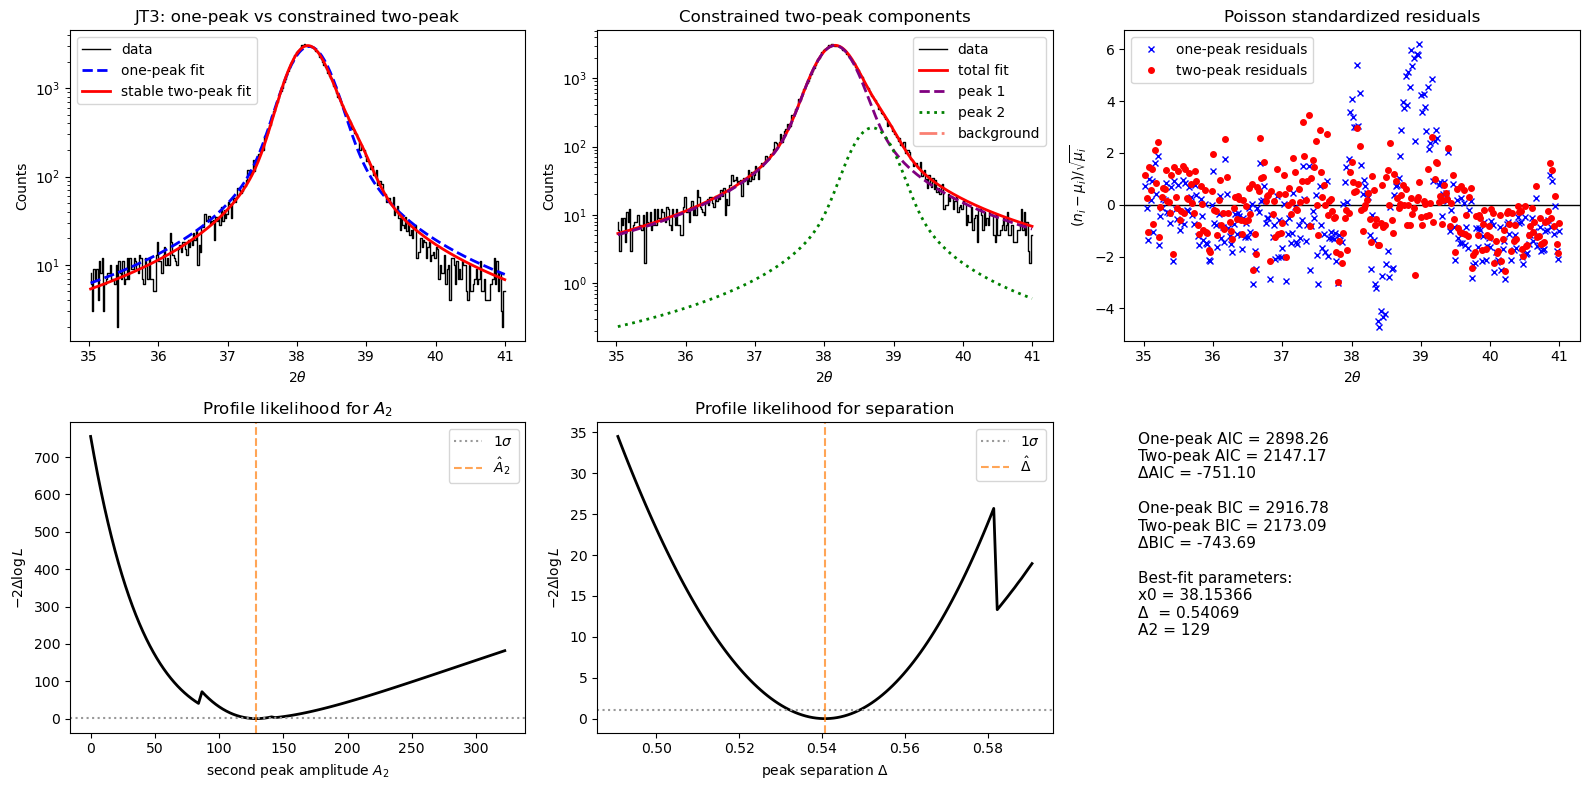

In [4]:
# look at one high signal and one low signal fit
f = files_low[7]
label = get_jt_label(f)
df = read_data(f)
c_low = ((df.x > 35) & (df.x < 41))

### This line calls the fitting class
fit = PeakFitXRD(df=df, mask=c_low, label=label)
fit.run_all(verbose=True, plot=True)

f = files_high[7]
label = get_jt_label(f)
df = read_data(f)
c_high = df.x > 35
fit = PeakFitXRD(df=df, mask=c_high, label=label)
fit.run_all(verbose=True, plot=True)





### Run the fits on all files from both datasets 

In [5]:
all_fits = []

for f in files_low:
    label = get_jt_label(f)
    df = read_data(f)
    c = c_low

    fit = PeakFitXRD(df=df, mask=c, label=label)
    fit.run_all(verbose=False, plot=False)
    all_fits.append(fit)
df_low = fits_to_dataframe(all_fits, pressures) #helper function also in XRD_fits.py 
                                                #to store all the fits in the list into 
                                                #a compact dataframe

all_fits = []

for f in files_high:
    label = get_jt_label(f)
    df = read_data(f)
    c = c_high

    fit = PeakFitXRD(df=df, mask=c, label=label)
    fit.run_all(verbose=False, plot=False)
    all_fits.append(fit)
df_high = fits_to_dataframe(all_fits, pressures)

#### save dataframe of fit parameters 

In [6]:
df_high.to_pickle("./data/processed_data/high_signal_XRD_df.pkl")
df_low.to_pickle("./data/processed_data/low_signal_XRD_df.pkl")
### to 
# df_high.read_pickle("./data/processed_data/high_signal_XRD_df.pkl")
# df_low.read_pickle("./data/processed_data/low_signal_XRD_df.pkl")

### Make plots of relevent fitting parameters

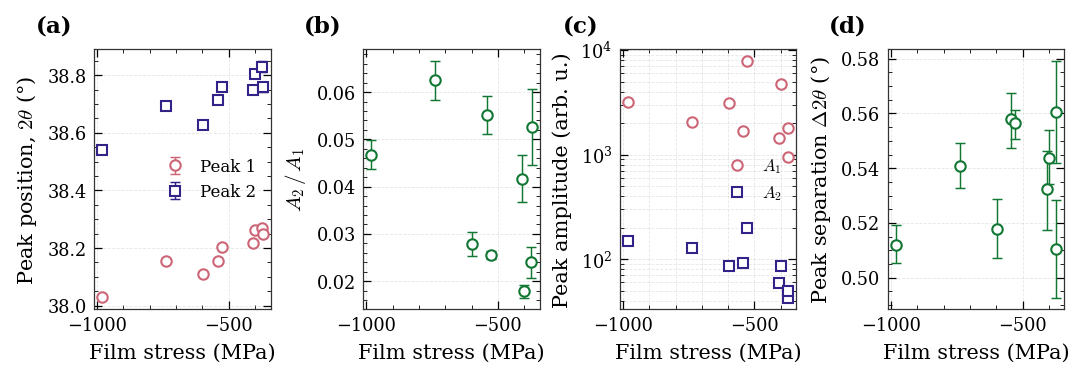

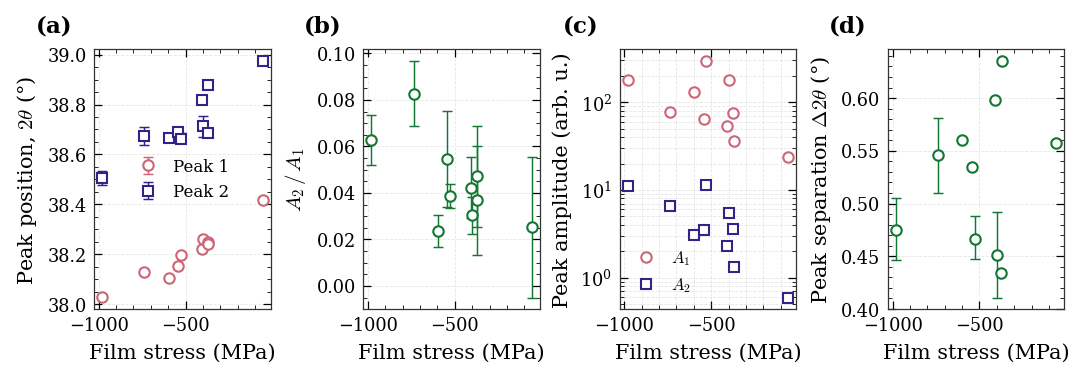

In [7]:
fig, axs = pltxrd.plot_xrd_fit_summary(df_high, stress_col="stress")
plt.show()

fig, axs = pltxrd.plot_xrd_fit_summary(df_low, stress_col="stress")
plt.show()

### Look at the slope of both the area fraction of the two peaks, and the peak seperation

slope=-5.011053578303246e-05+/-4.773523433115685e-06
slope=0.00020660866665003612+/-0.002562551878351576


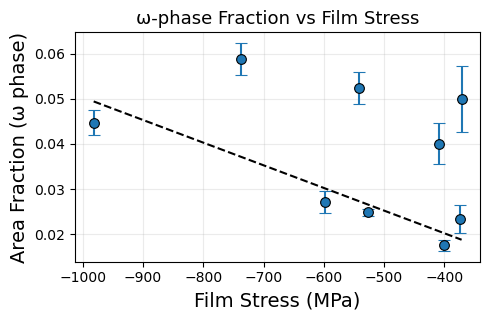

slope=-4.822408716641744e-05+/-1.7301278396400424e-05
slope=0.011219303256127215+/-0.01012113357005726


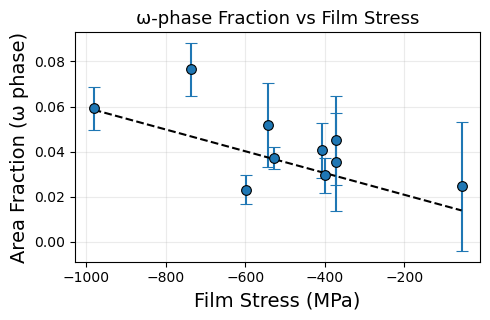

In [8]:
fig, ax = plt.subplots(figsize=(5,5*.66))

pltxrd.plot_area_fraction_vs_stress(df_high, ax=ax);

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(5,5*.66))

pltxrd.plot_area_fraction_vs_stress(df_low, ax=ax);

plt.tight_layout()
plt.show()

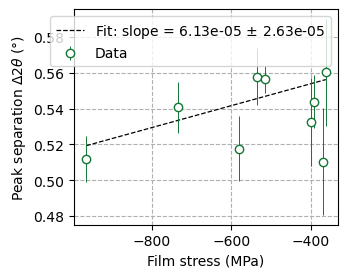

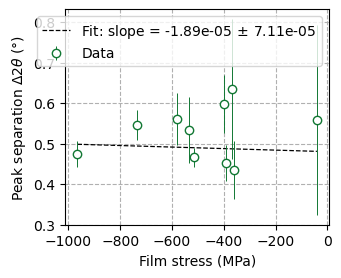

In [10]:
slope, slope_err = pltxrd.plot_delta_vs_stress_weighted(df_high)
slope, slope_err = pltxrd.plot_delta_vs_stress_weighted(df_low)

## Diagnostic plots to better understand the fits

See how the two peak model 'goodness of fit' depends on the stress. more negative delta AIC means the two peak model is more likely. less than around -10 means the two peak model is likely the best choice. 0 to -10 is a bit ambiguous 

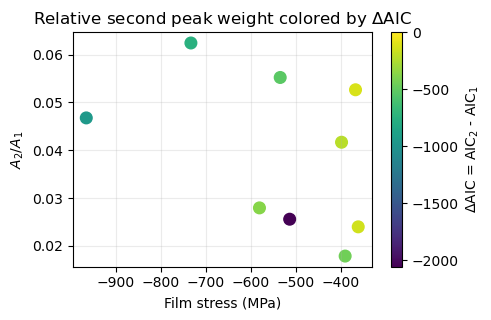

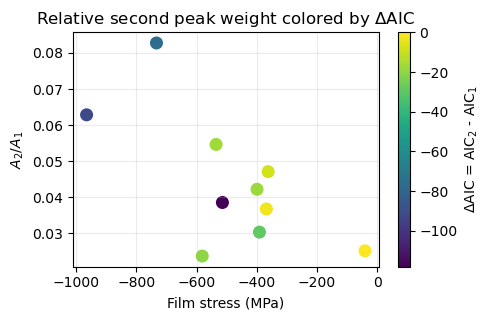

In [11]:
fig, ax = plt.subplots(figsize=(5,5*.66))

vmin = None#np.min(np.asarray(df_high["delta_AIC"],df_low["delta_AIC"]))
vmax = 0
sc = ax.scatter(
    df_high["stress"],
    df_high["A2_over_A1"],
    c=df_high["delta_AIC"],
    s=70,
    cmap="viridis",
    norm=mcolors.Normalize(vmin=vmin, vmax=vmax)
)

ax.set_xlabel("Film stress (MPa)")
ax.set_ylabel(r"$A_2/A_1$")
ax.set_title(r"Relative second peak weight colored by $\Delta$AIC")
ax.grid(True, alpha=0.25)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r"$\Delta$AIC = AIC$_2$ - AIC$_1$")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(5,5*.66))

sc = ax.scatter(
    df_low["stress"],
    df_low["A2_over_A1"],
    c=df_low["delta_AIC"],
    s=70,
    cmap="viridis",
    norm=mcolors.Normalize(vmin=vmin, vmax=vmax)
)

ax.set_xlabel("Film stress (MPa)")
ax.set_ylabel(r"$A_2/A_1$")
ax.set_title(r"Relative second peak weight colored by $\Delta$AIC")
ax.grid(True, alpha=0.25)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r"$\Delta$AIC = AIC$_2$ - AIC$_1$")

plt.tight_layout()
plt.show()

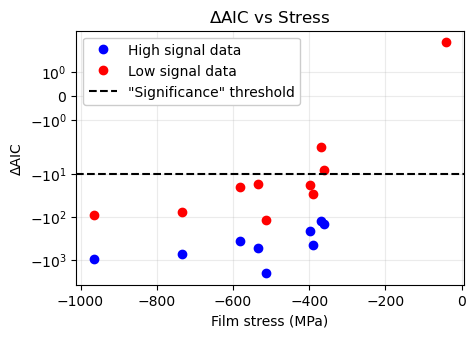

In [12]:
fig, ax = plt.subplots(figsize=(5,5*.66))
ax.plot(df_high["stress"], df_high["delta_AIC"], ls='none', marker='o', c='b', label='High signal data')
ax.plot(df_low["stress"], df_low["delta_AIC"], ls='none', marker='o', c='r',label='Low signal data')
ax.set_yscale('symlog')
ax.set_xlabel("Film stress (MPa)")
ax.set_ylabel(r"ΔAIC")
ax.grid(True, alpha=0.25)
ax.set_title(r"$\Delta$AIC vs Stress")

ax.axhline(-10, linestyle='--', color='k', label='"Significance" threshold')
ax.legend(framealpha=1)


### Compare fit params between the two different datasets

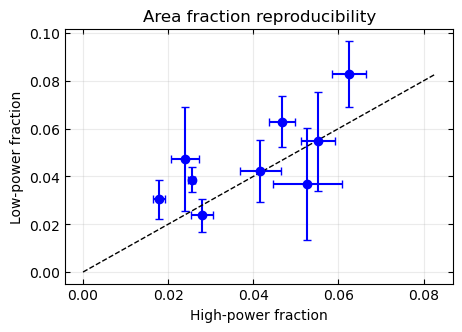

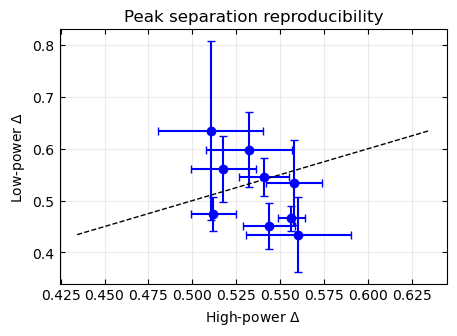

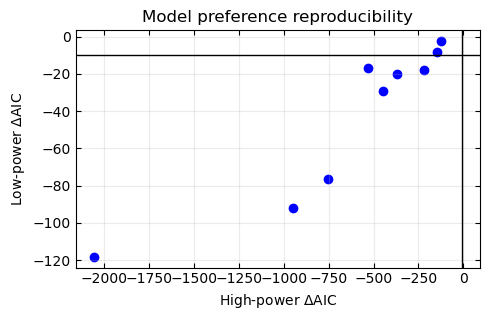

In [13]:
cols = ["label", "stress", "A2_over_A1", "A2_over_A1_err", "delta", "delta_err_hess", "delta_AIC"]

h = df_high[cols].rename(columns={c: c + "_high" for c in cols if c != "label"})
l = df_low[cols].rename(columns={c: c + "_low" for c in cols if c != "label"})

merged = h.merge(l, on="label")

fig, axs = plt.subplots( figsize=(5,5*.66))

axs.errorbar(
    merged["A2_over_A1_high"],
    merged["A2_over_A1_low"],
    xerr=merged["A2_over_A1_err_high"],
    yerr=merged["A2_over_A1_err_low"],
    fmt="o",
    capsize=3, color='b'
)
m = np.nanmax([merged["A2_over_A1_high"].max(), merged["A2_over_A1_low"].max()])
axs.plot([0,m], [0,m], "k--", lw=1)
axs.set_xlabel("High-power fraction")
axs.set_ylabel("Low-power fraction")
axs.set_title("Area fraction reproducibility")
axs.grid(True, alpha=0.25)
axs.tick_params(direction="in", top=True, right=True)

fig, axs = plt.subplots( figsize=(5,5*.66))
axs.errorbar(
    merged["delta_high"],
    merged["delta_low"],
    xerr=merged["delta_err_hess_high"],
    yerr=merged["delta_err_hess_low"],
    fmt="o",
    capsize=3, color='b'
)
m0 = np.nanmin([merged["delta_high"].min(), merged["delta_low"].min()])
m1 = np.nanmax([merged["delta_high"].max(), merged["delta_low"].max()])
axs.plot([m0,m1], [m0,m1], "k--", lw=1)
axs.set_xlabel(r"High-power $\Delta$")
axs.set_ylabel(r"Low-power $\Delta$")
axs.set_title(r"Peak separation reproducibility")
axs.grid(True, alpha=0.25)
axs.tick_params(direction="in", top=True, right=True)

fig, axs = plt.subplots( figsize=(5,5*.66))

axs.scatter(merged["delta_AIC_high"], merged["delta_AIC_low"], color='b')
axs.axhline(-10, color="k", lw=1)
axs.axvline(-10, color="k", lw=1)
axs.set_xlabel(r"High-power $\Delta$AIC")
axs.set_ylabel(r"Low-power $\Delta$AIC")
axs.set_title("Model preference reproducibility")
axs.grid(True, alpha=0.25)
axs.tick_params(direction="in", top=True, right=True)




plt.tight_layout()
plt.show()

#### check correlations between fit params

In [14]:


np.corrcoef(df_high["A2"], df_high["delta"])

array([[1.       , 0.1216531],
       [0.1216531, 1.       ]])

In [15]:
np.corrcoef(df_high["sigma"], df_high["delta"])

array([[1.       , 0.2333771],
       [0.2333771, 1.       ]])

In [16]:
np.corrcoef(df_low["sigma"], df_low["delta"])

array([[1.        , 0.80611854],
       [0.80611854, 1.        ]])

In [17]:
np.corrcoef(df_low["A2"], df_low["delta"])

array([[ 1.        , -0.61060206],
       [-0.61060206,  1.        ]])